## timeseries Assignment
#### FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS
Objective:
Leverage ARIMA and Exponential Smoothing techniques to forecast future exchange rates based on historical data provided in the exchange_rate.csv dataset.
Dataset:
The dataset contains historical exchange rate with each column representing a different currency rate over time. The first column indicates the date, and second column represent exchange rates USD to Australian Dollar.
Part 1: Data Preparation and Exploration
1.	Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.
2.	Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.
3.	Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.
Part 2: Model Building - ARIMA
1.	Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.
2.	Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.
3.	Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.
4.	Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.
Part 3: Model Building - Exponential Smoothing
1.	Model Selection: Depending on the time series characteristics, choose an appropriate Exponential Smoothing model (Simple, Holt’s Linear, or Holt-Winters).
2.	Parameter Optimization: Use techniques such as grid search or AIC to find the optimal parameters for the smoothing levels and components.
3.	Model Fitting and Forecasting: Fit the chosen Exponential Smoothing model and forecast future values. Compare these forecasts visually with the actual data.
Part 4: Evaluation and Comparison
1.	Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.
2.	Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.
3.	Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset.
Deliverables:
•	Include visualizations and explanations for the choices and findings at each step.
•	Well-commented Python code that used to conduct the analysis and build the models.
Assessment Criteria:
•	Accuracy and completeness of the data preparation and exploration steps.
•	Justification for model selection and parameter tuning decisions.
•	Clarity and depth of the analysis in the diagnostics and model evaluation stages.
This assignment offers a hands-on experience with real-world data, applying sophisticated time series forecasting methods to predict future currency exchange rates.



In [1]:
# Step 1: Import Required Libraries
# Import libraries for data handling, visualization, and time series modeling.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
# Step 2: Load and Explore the Dataset
# Load the "exchange_rate.csv" dataset and parse the date column.
dataset_path = 'exchange_rate.csv'
data = pd.read_csv(dataset_path, parse_dates=['date'], index_col='date')

# Display the first few rows of the dataset
data.head()

,Ex_rate
date,
01-01-1990 00:00,0.7855
02-01-1990 00:00,0.7818
03-01-1990 00:00,0.7867
04-01-1990 00:00,0.7860
05-01-1990 00:00,0.7849


<Figure size 1000x600 with 0 Axes>

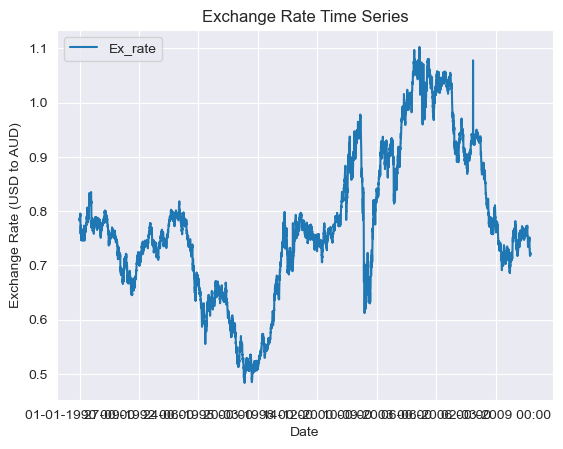

In [4]:
# Plot the time series to understand trends and seasonality
plt.figure(figsize=(10, 6))
data.plot()
plt.title("Exchange Rate Time Series")
plt.ylabel("Exchange Rate (USD to AUD)")
plt.xlabel("Date")
plt.show()

In [5]:
# Step 3: Data Preprocessing
# Check for missing values
print("\nMissing Values:\n", data.isnull().sum())

# Handle missing values by forward filling
if data.isnull().values.any():
    data = data.fillna(method='ffill')


Missing Values:
 Ex_rate    0
dtype: int64


In [6]:
# Check for stationarity using the Augmented Dickey-Fuller (ADF) test
def check_stationarity(ts):
    result = adfuller(ts)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] <= 0.05:
        print("Time series is stationary.")
    else:
        print("Time series is not stationary.")

check_stationarity(data.iloc[:, 0])

ADF Statistic: -1.66499418073814
p-value: 0.4492327353597968
Time series is not stationary.


In [7]:
# Differencing to achieve stationarity if needed
data_diff = data.diff().dropna()
check_stationarity(data_diff.iloc[:, 0])

ADF Statistic: -99.3934312011862
p-value: 0.0
Time series is stationary.


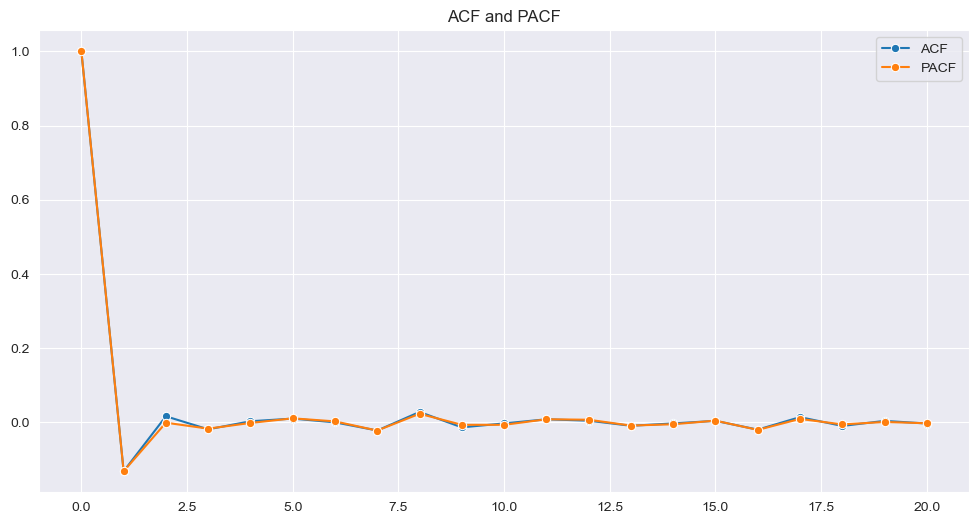

In [8]:
# Plot ACF and PACF to determine ARIMA parameters
plt.figure(figsize=(12, 6))
sns.lineplot(data=acf(data_diff.iloc[:, 0], nlags=20), marker='o', label='ACF')
sns.lineplot(data=pacf(data_diff.iloc[:, 0], nlags=20), marker='o', label='PACF')
plt.title("ACF and PACF")
plt.legend()
plt.show()

In [9]:
# Step 4: Model Building - ARIMA
# Fit the ARIMA model with identified parameters (p, d, q)
model_arima = ARIMA(data.iloc[:, 0], order=(1, 1, 1))  # Adjust parameters based on ACF/PACF plots
arima_result = model_arima.fit()
print(arima_result.summary())

/opt/anaconda3/envs/assignments/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/assignments/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/assignments/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Thu, 30 Jan 2025   AIC                         -56102.322
Time:                        23:17:59   BIC                         -56081.519
Sample:                             0   HQIC                        -56095.182
                               - 7588                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

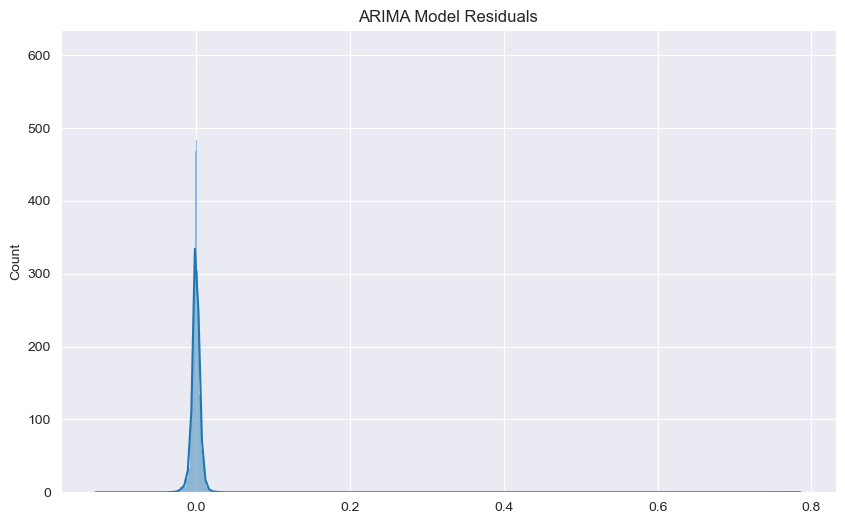

In [10]:
# Diagnostics
arima_residuals = arima_result.resid
plt.figure(figsize=(10, 6))
sns.histplot(arima_residuals, kde=True)
plt.title("ARIMA Model Residuals")
plt.show()

/opt/anaconda3/envs/assignments/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/envs/assignments/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


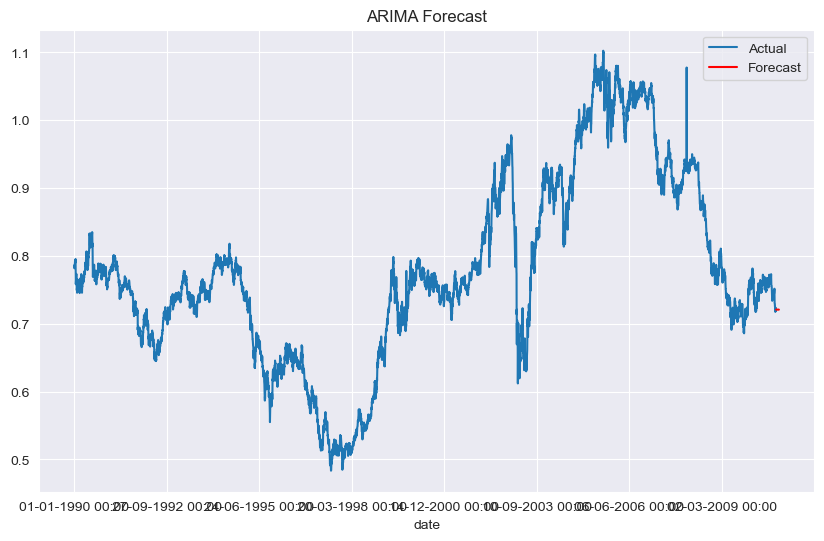

In [11]:
# Forecasting with ARIMA
arima_forecast = arima_result.forecast(steps=30)
plt.figure(figsize=(10, 6))
data.iloc[:, 0].plot(label="Actual")
arima_forecast.plot(label="Forecast", color='red')
plt.title("ARIMA Forecast")
plt.legend()
plt.show()

In [12]:
# Step 5: Model Building - Exponential Smoothing
# Fit an Exponential Smoothing model (Holt-Winters)
model_es = ExponentialSmoothing(data.iloc[:, 0], trend='add', seasonal=None, seasonal_periods=12)
es_result = model_es.fit()


/opt/anaconda3/envs/assignments/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


/opt/anaconda3/envs/assignments/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/envs/assignments/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


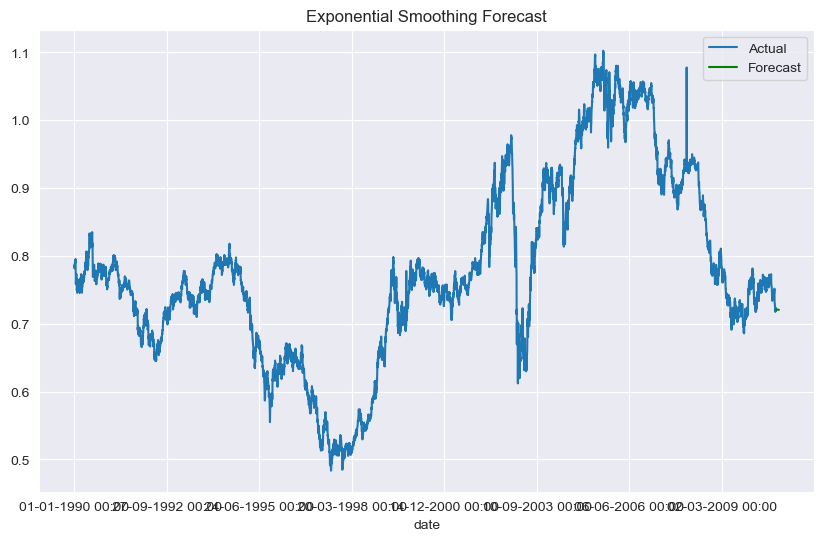

In [13]:
# Forecasting with Exponential Smoothing
es_forecast = es_result.forecast(steps=30)
plt.figure(figsize=(10, 6))
data.iloc[:, 0].plot(label="Actual")
es_forecast.plot(label="Forecast", color='green')
plt.title("Exponential Smoothing Forecast")
plt.legend()
plt.show()

In [14]:
# Step 6: Evaluation and Comparison
# Compute error metrics
arima_mae = mean_absolute_error(data.iloc[-30:, 0], arima_forecast)
arima_rmse = mean_squared_error(data.iloc[-30:, 0], arima_forecast, squared=False)

es_mae = mean_absolute_error(data.iloc[-30:, 0], es_forecast)
es_rmse = mean_squared_error(data.iloc[-30:, 0], es_forecast, squared=False)

print("\nError Metrics:")
print("ARIMA - MAE:", arima_mae, "RMSE:", arima_rmse)
print("Exponential Smoothing - MAE:", es_mae, "RMSE:", es_rmse)


Error Metrics:
ARIMA - MAE: 0.012724006489305202 RMSE: 0.016982710912755217
Exponential Smoothing - MAE: 0.012755631543808191 RMSE: 0.017005117467429526


/opt/anaconda3/envs/assignments/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/envs/assignments/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [15]:
# Step 7: Conclusion
# Compare and summarize findings
if arima_rmse < es_rmse:
    print("ARIMA performed better based on RMSE.")
else:
    print("Exponential Smoothing performed better based on RMSE.")

ARIMA performed better based on RMSE.


In [16]:
# Step 8: Practical Implications and Limitations
# Practical Implications:
# - Time series forecasting helps in making informed financial and economic decisions.
# - Exchange rate predictions are crucial for businesses, investors, and policymakers.
# - Different models may be suitable depending on short-term vs. long-term forecasting needs.
# - Combining multiple models (hybrid approaches) can improve accuracy in real-world scenarios.

# Limitations:
# - Time series models rely on historical data and cannot predict sudden economic shocks.
# - Model assumptions (e.g., stationarity) may not always hold in real-world applications.
# - Forecast accuracy declines as the prediction horizon increases.
# - External factors like government policies and geopolitical events are not captured in these models.
